In [1]:
# reading data and importing lib
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("student_dataset.csv")

In [3]:
# checking data
data.head()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
0,1,Male,5.7,83.3,72.1,76.9,Pass
1,2,Male,4.2,80.6,77.1,66.0,Pass
2,3,Male,2.3,76.0,63.3,45.4,Pass
3,4,Female,2.2,72.3,95.1,60.5,Pass
4,5,Female,4.0,86.9,81.1,64.9,Pass


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      300 non-null    int64  
 1   Gender          290 non-null    str    
 2   Study_Hours     288 non-null    float64
 3   Attendance      290 non-null    float64
 4   Previous_Score  288 non-null    float64
 5   Final_Score     300 non-null    float64
 6   Result          300 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 16.5 KB


In [5]:
#null values
data.isnull().sum()

Student_ID         0
Gender            10
Study_Hours       12
Attendance        10
Previous_Score    12
Final_Score        0
Result             0
dtype: int64

In [6]:
data.drop_duplicates()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
0,1,Male,5.7,83.3,72.1,76.9,Pass
1,2,Male,4.2,80.6,77.1,66.0,Pass
2,3,Male,2.3,76.0,63.3,45.4,Pass
3,4,Female,2.2,72.3,95.1,60.5,Pass
4,5,Female,4.0,86.9,81.1,64.9,Pass
...,...,...,...,...,...,...,...
295,296,Female,5.3,91.4,45.2,62.5,Pass
296,297,Female,3.3,74.9,51.0,43.0,Pass
297,298,Male,6.4,88.5,50.4,72.2,Pass
298,299,Male,5.3,80.4,47.6,52.5,Pass


In [7]:
#outliers
# select num col
num=[]
cat=[]
for x in data.columns:
    if data[x].dtype=="str":
        cat.append(x)

    else:
        num.append(x)
print("cat",cat)
print("num",num)

cat ['Gender', 'Result']
num ['Student_ID', 'Study_Hours', 'Attendance', 'Previous_Score', 'Final_Score']


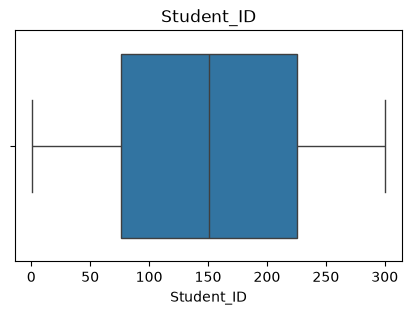

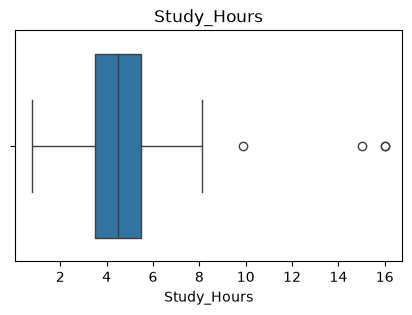

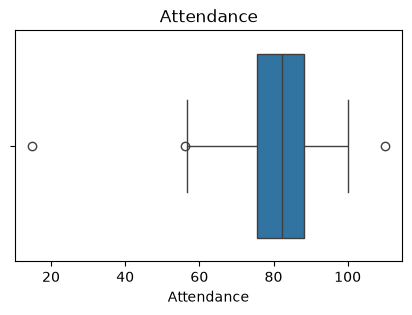

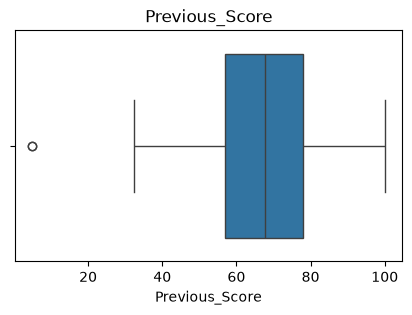

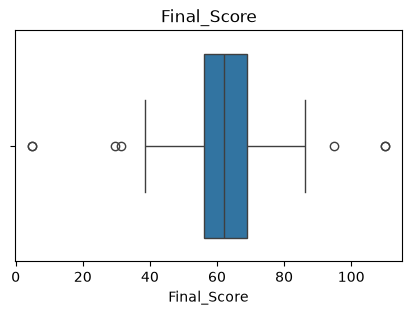

In [8]:
#box plot 
for col in num:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

In [9]:
for col in num:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower= Q1 - 1.5 * IQR
    upper= Q3 + 1.5 * IQR
    outlires= data[(data[col]<lower) | (data[col]>upper)]
    print(f"{col}: {len(outlires)}) outliners")

Student_ID: 0) outliners
Study_Hours: 4) outliners
Attendance: 3) outliners
Previous_Score: 2) outliners
Final_Score: 7) outliners


In [10]:
Q1 = data['Study_Hours'].quantile(0.25)
Q3 = data['Study_Hours'].quantile(0.75)
IQR = Q3 - Q1
    
lower= Q1 - 1.5 * IQR
upper= Q3 + 1.5 * IQR
data[(data['Study_Hours'] < lower) | (data['Study_Hours'] > upper)].index



Index([19, 40, 79, 149], dtype='int64')

In [11]:
data=data.drop([19,40,79,149])

In [12]:
data.sample()

,Student_ID,Gender,Study_Hours,Attendance,Previous_Score,Final_Score,Result
136,137,Male,5.4,90.5,61.7,60.6,Pass


In [13]:
data.columns

Index(['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', 'Result'],
      dtype='str')

In [14]:
data['Attendance']=data['Attendance'].fillna(data['Attendance'].median())

In [15]:
data['Study_Hours']=data['Study_Hours'].fillna(data['Study_Hours'].mean())

In [16]:
data['Previous_Score']=data['Previous_Score'].fillna(data['Previous_Score'].median())

In [17]:
data.isnull().sum()

Student_ID         0
Gender            10
Study_Hours        0
Attendance         0
Previous_Score     0
Final_Score        0
Result             0
dtype: int64

In [18]:
data['Gender']=data['Gender'].fillna("Male")

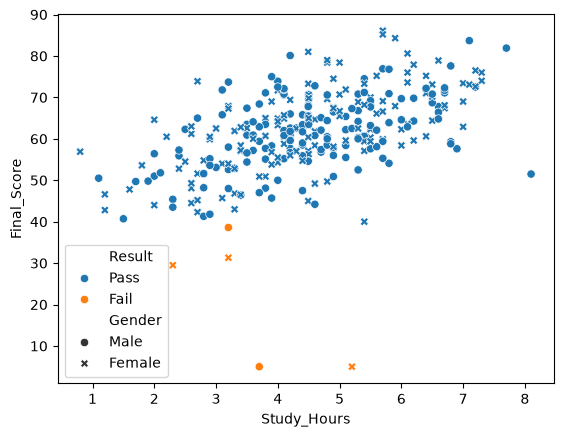

In [19]:
#plot
sns.scatterplot(data=data,x='Study_Hours',y='Final_Score',hue='Result',style='Gender')
plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

In [21]:
cat

['Gender', 'Result']

In [22]:
data['Gender']=LE.fit_transform(data['Gender'])

In [23]:
data['Result']=LE.fit_transform(data['Result'])

In [24]:
data.columns


Index(['Student_ID', 'Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', 'Result'],
      dtype='str')

In [25]:
x=data.loc[:,['Gender', 'Study_Hours', 'Attendance', 'Previous_Score',
       'Final_Score', ]]
y=data['Result']

In [26]:
from sklearn.linear_model import LogisticRegression
LOGR=LogisticRegression()

In [27]:
LOGR.fit(x,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [28]:
LOGR.predict(x)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [30]:
LOGR.score(x,y)

1.0

In [32]:
import joblib
joblib.dump(LE,"LablE.pkl")
joblib.dump(LOGR,"Logreg.pkl")

['Logreg.pkl']